# 🎓 GPA Prediction with Dummy Variables & OLS Regression

**Author:** Shavkatjon Yuldashev  
**Email:** [Shavkatjon.yuldashev.0411@gmail.com]  

---

**Topic:** Handling Categorical Predictors | OLS Regression | Model Diagnostics | Scaled Predictions  
**Date:** 2026-01-20

---

## 📋 Notebook Overview

This notebook is a **complete end-to-end regression analysis** that covers:

| # | Section | Description |
|---|---------|-------------|
| 1 | **Data Loading & Preprocessing** | Load CSV, map categorical variables, clean data |
| 2 | **Exploratory Data Analysis** | Descriptive statistics, distributions |
| 3 | **OLS Baseline Regression** | Fit model using SAT + Attendance to predict GPA |
| 4 | **Visualization** | Scatter plots + conditional regression lines |
| 5 | **Model Diagnostics** | VIF, Durbin-Watson, Breusch-Pagan, Residual plots |
| 6 | **Train / Test Split & RMSE** | Predictive performance evaluation |
| 7 | **Scaled OLS Model** | Standardized features for numerical stability |
| 8 | **Predictions** | Predict GPA for new students (both models) |
| 9 | **Conclusion** | Key insights and interpretation |

---

### 🧠 Core Concept: Dummy Variables
A **dummy variable** converts a categorical feature (`Yes/No`) into a numeric one (`1/0`), allowing it to be used in regression equations.  
Here, `Attendance` is our dummy variable — *did the student attend classes?*

---
## 📦 Section 1 — Import Libraries

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  IMPORTS
#  Standard data science stack + statsmodels for OLS + sklearn for ML utilities
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# ── Aesthetics ───────────────────────────────────────────────────────────────
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 🗂️ Section 2 — Load & Preprocess Data

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  LOAD DATA
#  Make sure 'dummy1.csv' is in the same folder as this notebook
# ─────────────────────────────────────────────────────────────────────────────

raw_data = pd.read_csv('dummy1.csv')

print(f'📐 Shape: {raw_data.shape[0]} rows × {raw_data.shape[1]} columns')
print(f'📌 Columns: {list(raw_data.columns)}')
raw_data.head()

📐 Shape: 84 rows × 3 columns
📌 Columns: ['SAT', 'GPA', 'Attendance']


,SAT,GPA,Attendance
0,1714,2.40,No
1,1664,2.52,No
2,1760,2.54,No
3,1685,2.74,No
4,1693,2.83,No


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  PREPROCESSING
#  • Map 'Yes' → 1  |  'No' → 0   (creates our dummy variable)
#  • Drop any rows with missing values
#  • Reset index for a clean slate
# ─────────────────────────────────────────────────────────────────────────────

data = raw_data.copy()
data['Attendance'] = data['Attendance'].map({'Yes': 1, 'No': 0})
data = data[['SAT', 'GPA', 'Attendance']].dropna().reset_index(drop=True)

print('✅ Preprocessing complete!')
print(f'   → Attendance mapped: No=0 | Yes=1')
print(f'   → Final shape: {data.shape}')
data.head(10)

✅ Preprocessing complete!
   → Attendance mapped: No=0 | Yes=1
   → Final shape: (84, 3)


,SAT,GPA,Attendance
0,1714,2.40,0
1,1664,2.52,0
2,1760,2.54,0
3,1685,2.74,0
4,1693,2.83,0
5,1670,2.91,0
6,1764,3.00,0
7,1764,3.00,0
8,1792,3.01,0
9,1850,3.01,0


---
## 🔍 Section 3 — Exploratory Data Analysis (EDA)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  DESCRIPTIVE STATISTICS
#  Quick summary of central tendency, spread, and range for each variable
# ─────────────────────────────────────────────────────────────────────────────

print('📊 Descriptive Statistics:')
data.describe().round(3)

📊 Descriptive Statistics:


,SAT,GPA,Attendance
count,84.000,84.000,84.000
mean,1845.274,3.330,0.464
std,104.531,0.272,0.502
min,1634.000,2.400,0.000
25%,1772.000,3.190,0.000
50%,1846.000,3.380,0.000
75%,1934.000,3.502,1.000
max,2050.000,3.810,1.000


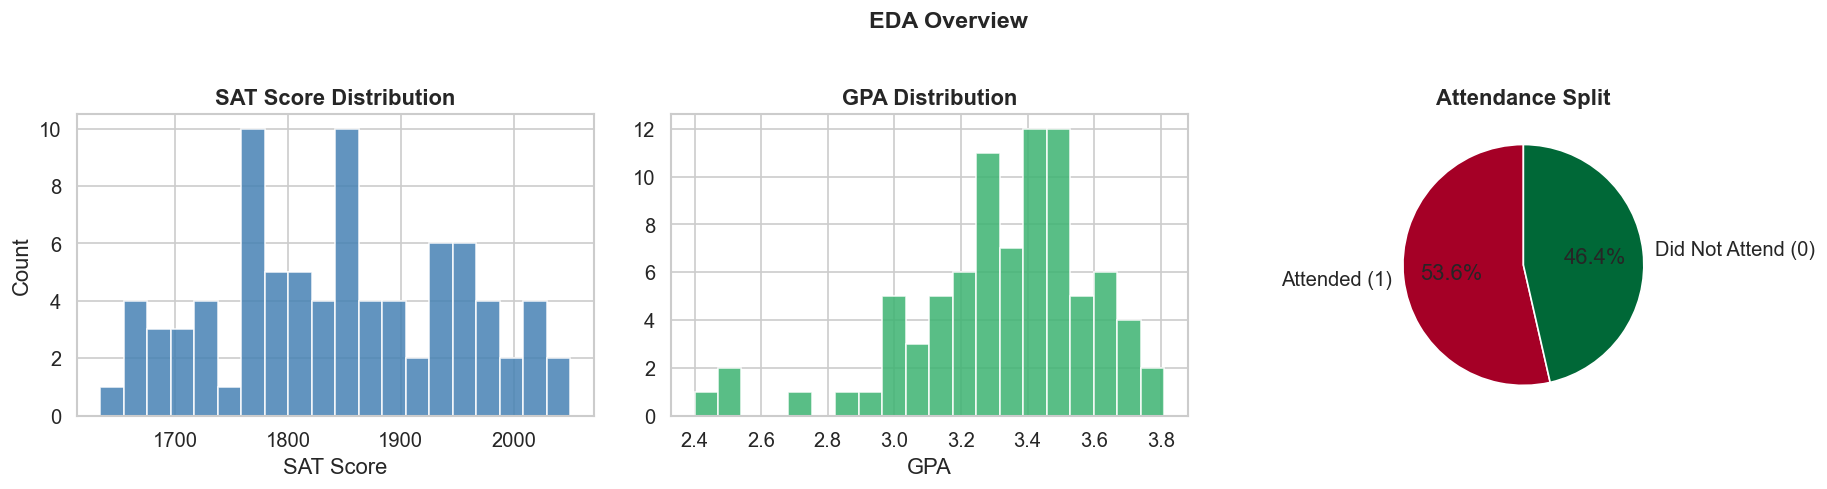

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  EDA PLOTS  ─  Distributions & Attendance Split
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# SAT distribution
axes[0].hist(data['SAT'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('SAT Score Distribution', fontweight='bold')
axes[0].set_xlabel('SAT Score')
axes[0].set_ylabel('Count')

# GPA distribution
axes[1].hist(data['GPA'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('GPA Distribution', fontweight='bold')
axes[1].set_xlabel('GPA')

# Attendance pie chart
att_counts = data['Attendance'].value_counts()
axes[2].pie(att_counts, labels=['Attended (1)', 'Did Not Attend (0)'],
            autopct='%1.1f%%', colors=['#a50026','#006837'], startangle=90)
axes[2].set_title('Attendance Split', fontweight='bold')

plt.suptitle('EDA Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 📈 Section 4 — OLS Baseline Regression

We fit an **Ordinary Least Squares** regression:

$$\text{GPA} = \beta_0 + \beta_1 \cdot \text{SAT} + \beta_2 \cdot \text{Attendance} + \varepsilon$$

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  DEFINE VARIABLES & FIT MODEL
# ─────────────────────────────────────────────────────────────────────────────

y = data['GPA']
X = data[['SAT', 'Attendance']]
X = sm.add_constant(X)   # adds intercept column 'const'

ols_res = sm.OLS(y, X).fit()
print(ols_res.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.19e-15
Time:                        17:17:17   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.0

---
## 🎨 Section 5 — Visualizations

We plot **two conditional regression lines** — one for students who attended and one for those who didn't.

- 🟢 **Green line** → Did not attend (`Attendance = 0`)
- 🔴 **Red line** → Attended (`Attendance = 1`)
- 🔵 **Blue line** → Original single regression (no dummy)

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  EXTRACT COEFFICIENTS DYNAMICALLY from the fitted model
#  (avoids hardcoding — if you retrain, values update automatically)
# ─────────────────────────────────────────────────────────────────────────────

b0       = ols_res.params['const']
b_sat    = ols_res.params['SAT']
b_attend = ols_res.params['Attendance']

# Predicted GPA lines for each attendance group
yhat_no  = b0 + b_sat * data['SAT']                  # Attendance = 0
yhat_yes = b0 + b_attend + b_sat * data['SAT']        # Attendance = 1
yhat_original = 0.0017 * data['SAT'] + 0.275          # baseline (no dummy)

print(f'Intercept (no attendance): {b0:.4f}')
print(f'Intercept (with attendance): {b0 + b_attend:.4f}')
print(f'SAT coefficient: {b_sat:.6f}')

Intercept (no attendance): 0.6439
Intercept (with attendance): 0.8665
SAT coefficient: 0.001400


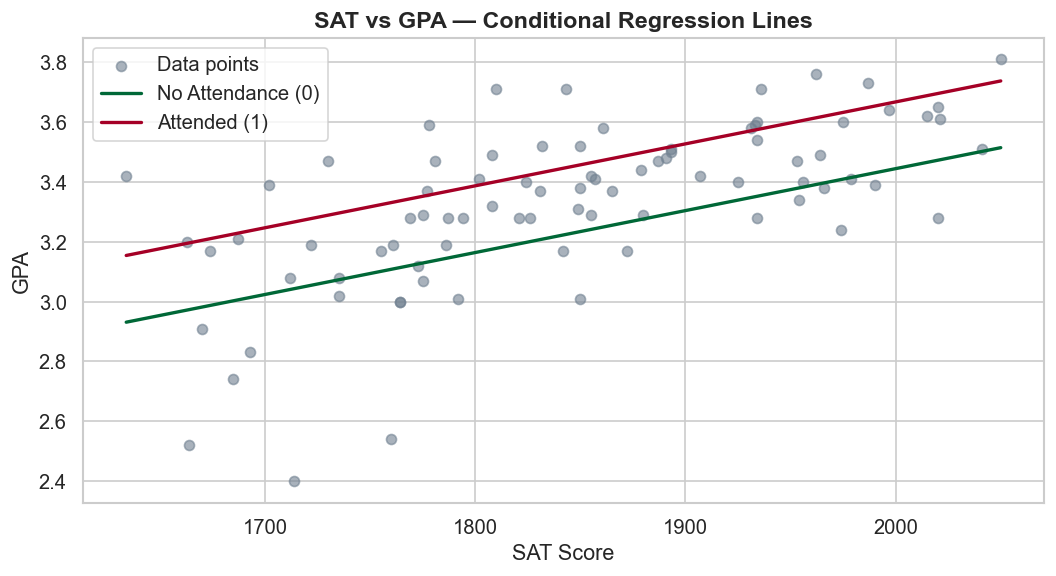

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  PLOT 1 — Basic scatter + two regression lines
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(9, 5))
plt.scatter(data['SAT'], data['GPA'], alpha=0.6, color='slategray', label='Data points')
plt.plot(data['SAT'].sort_values(), yhat_no.loc[data['SAT'].sort_values().index],
         lw=2, c='#006837', label='No Attendance (0)')
plt.plot(data['SAT'].sort_values(), yhat_yes.loc[data['SAT'].sort_values().index],
         lw=2, c='#a50026', label='Attended (1)')
plt.xlabel('SAT Score', fontsize=13)
plt.ylabel('GPA', fontsize=13)
plt.title('SAT vs GPA — Conditional Regression Lines', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

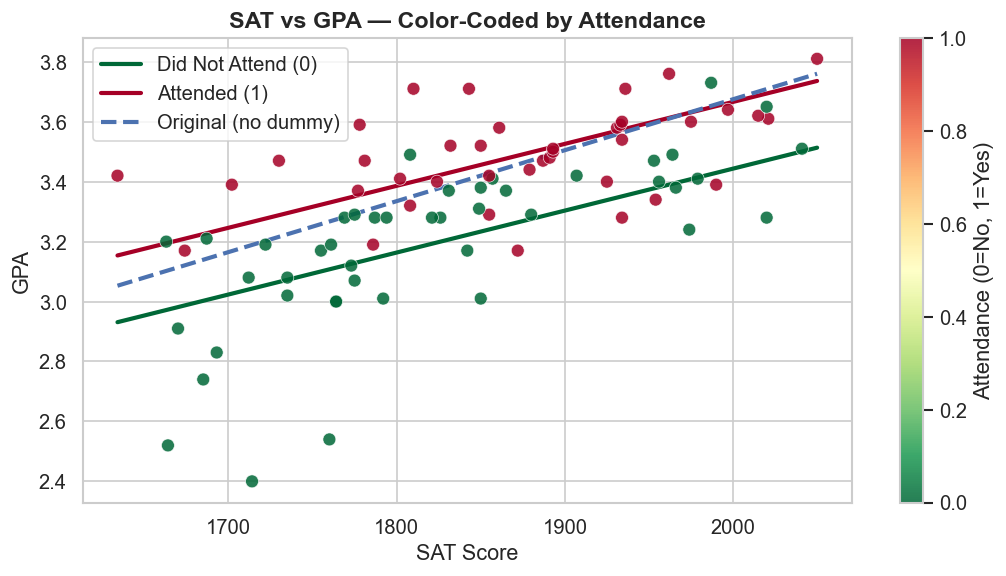

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  PLOT 2 — Color-coded data points by attendance + all three lines
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(9, 5))

# Points colored by Attendance (0=green, 1=red)
scatter = plt.scatter(data['SAT'], data['GPA'],
                      c=data['Attendance'], cmap='RdYlGn_r',
                      edgecolors='white', linewidth=0.4,
                      alpha=0.85, s=60, zorder=3)

sat_sorted = data['SAT'].sort_values()
plt.plot(sat_sorted, yhat_no.loc[sat_sorted.index],   lw=2.5, c='#006837', label='Did Not Attend (0)')
plt.plot(sat_sorted, yhat_yes.loc[sat_sorted.index],  lw=2.5, c='#a50026', label='Attended (1)')
plt.plot(sat_sorted, yhat_original.loc[sat_sorted.index], lw=2.5, c='#4C72B0', linestyle='--', label='Original (no dummy)')

plt.colorbar(scatter, label='Attendance (0=No, 1=Yes)')
plt.xlabel('SAT Score', fontsize=13)
plt.ylabel('GPA', fontsize=13)
plt.title('SAT vs GPA — Color-Coded by Attendance', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔬 Section 6 — Model Diagnostics

A good regression model must pass several statistical tests:

| Test | What it checks |
|------|---------------|
| **Condition Number** | Multicollinearity (values > 30 are concerning) |
| **VIF** | Per-variable multicollinearity (> 5 = problematic) |
| **Durbin-Watson** | Autocorrelation of residuals (ideal ≈ 2.0) |
| **Breusch-Pagan** | Heteroskedasticity (p < 0.05 = problem) |
| **Residual Plot** | Visual check — should show no pattern |
| **Q-Q Plot** | Normality of residuals — should follow 45° line |

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  CONDITION NUMBER  &  VIF
# ─────────────────────────────────────────────────────────────────────────────

print(f'📐 Condition Number : {ols_res.condition_number:.3e}')
print('   (Rule of thumb: < 30 = OK, 30–100 = moderate, > 100 = problematic)\n')

X_vif = X.drop(columns='const')
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print('📊 Variance Inflation Factors (VIF):')
print(vif_df.to_string(index=False))
print('   (VIF < 5 = acceptable, < 2.5 = excellent)')

📐 Condition Number : 3.348e+04
   (Rule of thumb: < 30 = OK, 30–100 = moderate, > 100 = problematic)

📊 Variance Inflation Factors (VIF):
  Variable     VIF
       SAT 1.90957
Attendance 1.90957
   (VIF < 5 = acceptable, < 2.5 = excellent)


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  DURBIN-WATSON  &  BREUSCH-PAGAN
# ─────────────────────────────────────────────────────────────────────────────

dw = durbin_watson(ols_res.resid)
print(f'🔁 Durbin-Watson Statistic : {dw:.3f}')
print(   '   (Ideal ≈ 2.0 | < 1.5 = positive autocorrelation | > 2.5 = negative autocorrelation)\n')

bp_test   = het_breuschpagan(ols_res.resid, ols_res.model.exog)
bp_labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
print('📋 Breusch-Pagan Heteroskedasticity Test:')
for label, value in zip(bp_labels, bp_test):
    print(f'   {label:<18}: {value:.4f}')
print('   (p > 0.05 → homoskedastic residuals ✅)')

🔁 Durbin-Watson Statistic : 1.009
   (Ideal ≈ 2.0 | < 1.5 = positive autocorrelation | > 2.5 = negative autocorrelation)

📋 Breusch-Pagan Heteroskedasticity Test:
   LM Statistic      : 5.4561
   LM p-value        : 0.0653
   F Statistic       : 2.8134
   F p-value         : 0.0659
   (p > 0.05 → homoskedastic residuals ✅)


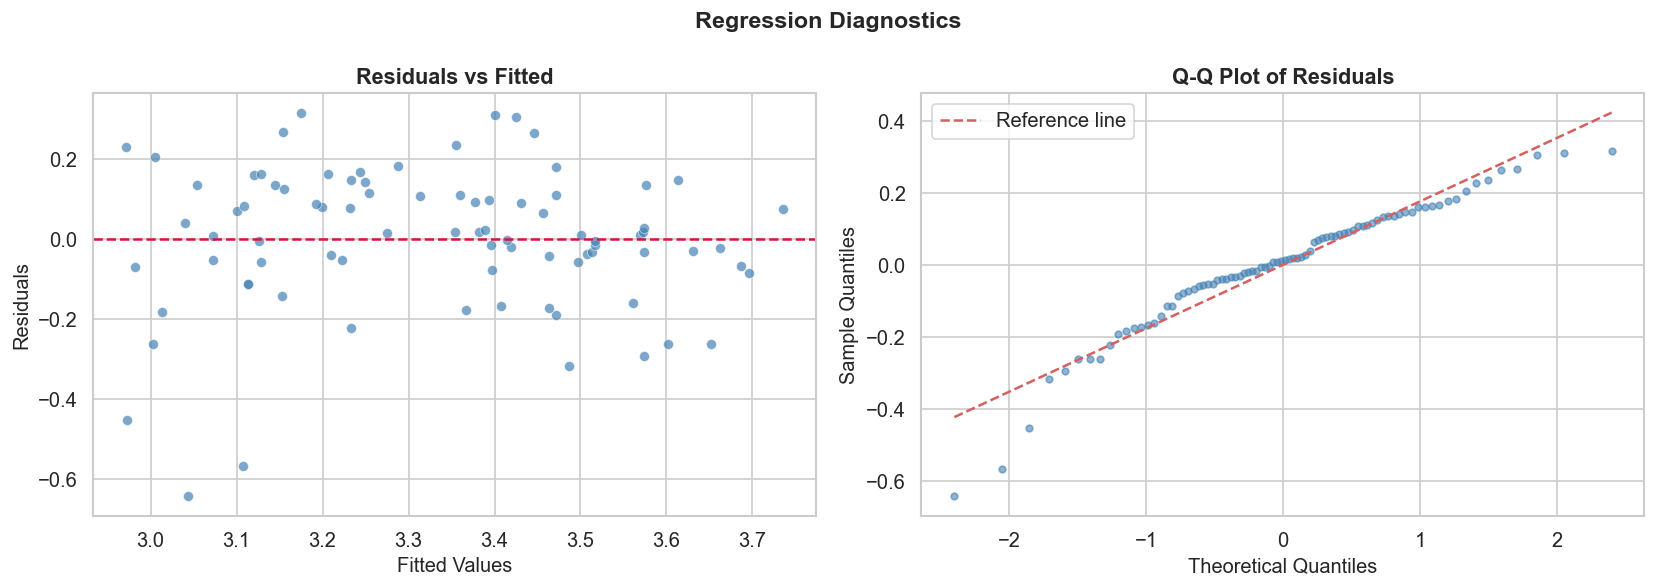

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
#  RESIDUAL PLOTS — Residuals vs Fitted  &  Q-Q Plot
# ─────────────────────────────────────────────────────────────────────────────

fitted    = ols_res.fittedvalues
residuals = ols_res.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Residuals vs Fitted ---
axes[0].scatter(fitted, residuals, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.4)
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Residuals vs Fitted', fontsize=13, fontweight='bold')

# --- Q-Q Plot ---
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[1].plot(osm, osr, 'o', alpha=0.6, color='steelblue', markersize=4)
axes[1].plot(osm, slope*np.array(osm)+intercept, 'r--', linewidth=1.5, label=f'Reference line')
axes[1].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[1].set_ylabel('Sample Quantiles', fontsize=12)
axes[1].set_title('Q-Q Plot of Residuals', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Regression Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

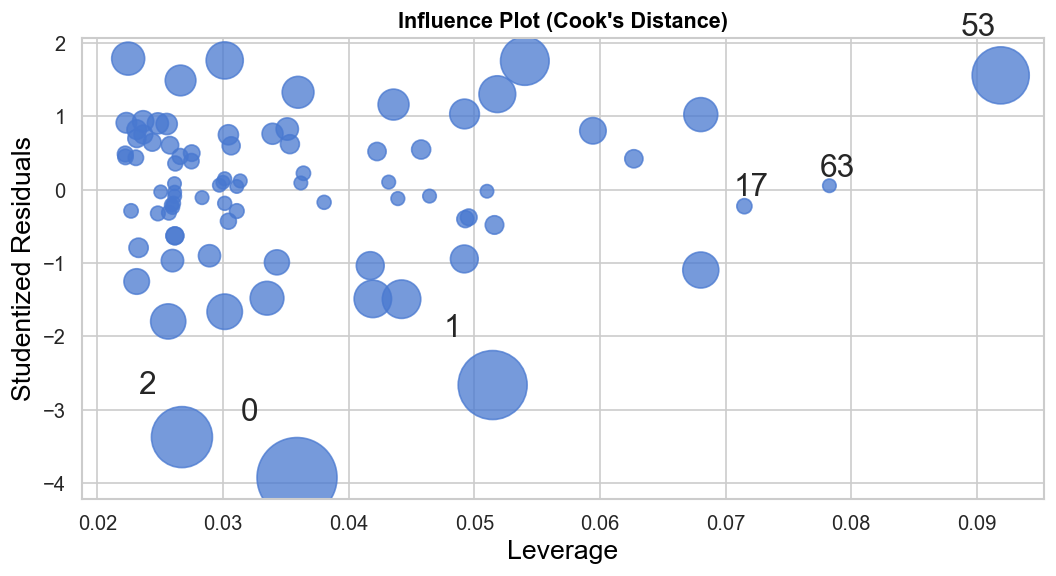

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
#  INFLUENCE PLOT — Detect outliers / high-leverage points
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))
sm.graphics.influence_plot(ols_res, criterion='cooks', ax=ax)
ax.set_title('Influence Plot (Cook\'s Distance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧪 Section 7 — Train / Test Split & RMSE

We use an **80/20 split** to evaluate out-of-sample predictive accuracy.  
**RMSE** (Root Mean Squared Error) tells us the average prediction error in GPA units.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
#  TRAIN / TEST SPLIT
#  80% training, 20% testing | random_state=42 for reproducibility
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'📏 Training set size : {len(X_train)} samples')
print(f'📏 Test set size     : {len(X_test)} samples')

model_tt  = sm.OLS(y_train, X_train).fit()
y_pred    = model_tt.predict(X_test)
rmse      = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'\n📉 Test RMSE : {rmse:.4f} GPA points')
print(f'   (Lower is better — this means our average prediction error is {rmse:.2f} GPA points)')

📏 Training set size : 67 samples
📏 Test set size     : 17 samples

📉 Test RMSE : 0.2049 GPA points
   (Lower is better — this means our average prediction error is 0.20 GPA points)


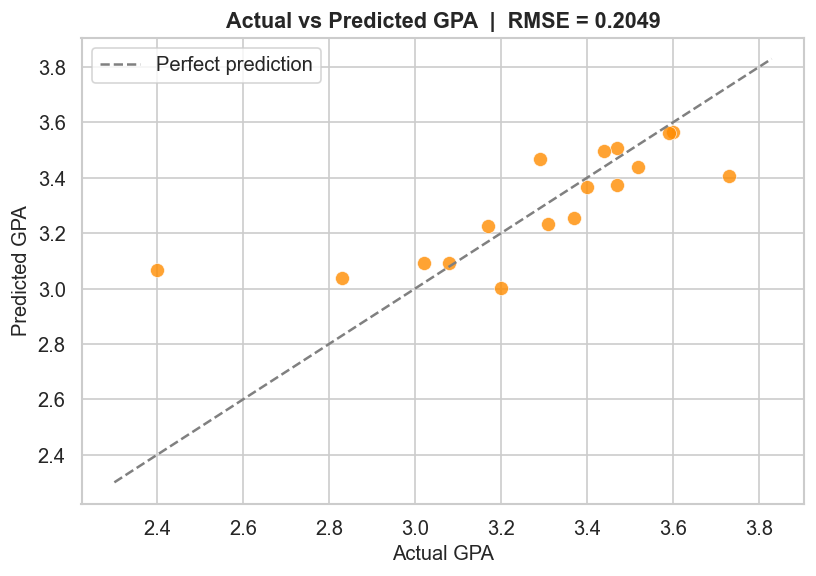

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  VISUAL — Actual vs Predicted GPA on the test set
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.8, color='darkorange', edgecolors='white', linewidth=0.4, s=70)
lims = [min(y_test.min(), y_pred.min()) - 0.1, max(y_test.max(), y_pred.max()) + 0.1]
plt.plot(lims, lims, '--', color='gray', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual GPA', fontsize=12)
plt.ylabel('Predicted GPA', fontsize=12)
plt.title(f'Actual vs Predicted GPA  |  RMSE = {rmse:.4f}', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## ⚖️ Section 8 — Scaled OLS Model

**Why scale?**  
SAT scores range in the thousands while GPA is between 0–4.  
Standardizing SAT (`mean=0, std=1`) reduces the **condition number**, improving **numerical stability** and making coefficients directly comparable.

> _Standardized coefficient = effect per 1 standard deviation change in SAT_

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  STANDARDIZE SAT  &  FIT SCALED MODEL
# ─────────────────────────────────────────────────────────────────────────────

scaler        = StandardScaler()
data['SAT_s'] = scaler.fit_transform(data[['SAT']])

Xs         = sm.add_constant(data[['SAT_s', 'Attendance']])
ys         = data['GPA']
ols_scaled = sm.OLS(ys, Xs).fit()

print('📊 Scaled Model Summary:')
print(ols_scaled.summary())

📊 Scaled Model Summary:
                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.19e-15
Time:                        17:17:29   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2269      0

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  COMPARE: Original vs Scaled Model
# ─────────────────────────────────────────────────────────────────────────────

comparison = pd.DataFrame({
    'Original Model': ols_res.params,
    'Scaled Model'  : ols_scaled.params.rename({'SAT_s': 'SAT / SAT_s'})
}).fillna('—')

print('🔍 Coefficient Comparison (note: SAT_s is per 1 std deviation):')
print(comparison.to_string())
print(f'\n📐 Original condition number : {ols_res.condition_number:.3e}')
print(f'📐 Scaled  condition number  : {ols_scaled.condition_number:.3e}')
print(f'\n✏️  Standardized SAT coefficient: {ols_scaled.params["SAT_s"]:.4f} GPA per 1 SD increase in SAT')

🔍 Coefficient Comparison (note: SAT_s is per 1 std deviation):
            Original Model Scaled Model
Attendance        0.222644     0.222644
SAT                 0.0014            —
SAT / SAT_s              —     0.145449
const              0.64385     3.226868

📐 Original condition number : 3.348e+04
📐 Scaled  condition number  : 2.646e+00

✏️  Standardized SAT coefficient: 0.1454 GPA per 1 SD increase in SAT


---
## 🎯 Section 9 — Predictions for New Students

Let's predict the GPA for two hypothetical students:

| Student | SAT | Attended? |
|---------|-----|----------|
| **Bob** | 1700 | ❌ No |
| **Alice** | 1670 | ✅ Yes |

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#  PREDICTION — Original (Unscaled) Model
# ─────────────────────────────────────────────────────────────────────────────

new_X = pd.DataFrame({'const': 1, 'SAT': [1700, 1670], 'Attendance': [0, 1]})
new_X = new_X[['const', 'SAT', 'Attendance']]   # column order must match training X

predictions           = ols_res.predict(new_X)
predictions.index     = ['Bob', 'Alice']

pred_df = pd.DataFrame({
    'SAT'       : [1700, 1670],
    'Attendance': ['No (0)', 'Yes (1)'],
    'Predicted GPA (original model)': predictions.round(4).values
}, index=['Bob', 'Alice'])

print('📌 Predictions — Original Model:')
pred_df

📌 Predictions — Original Model:


,SAT,Attendance,Predicted GPA (original model)
Bob,1700,No (0),3.0235
Alice,1670,Yes (1),3.2042


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  PREDICTION — Scaled Model
#  Must apply the SAME scaler used during training to transform new SAT values
# ─────────────────────────────────────────────────────────────────────────────

sat_scaled = scaler.transform(np.array([1700, 1670]).reshape(-1, 1)).flatten()

new_scaled = pd.DataFrame({'const': 1, 'SAT_s': sat_scaled, 'Attendance': [0, 1]})
new_scaled = new_scaled[['const', 'SAT_s', 'Attendance']]

pred_scaled         = ols_scaled.predict(new_scaled)
pred_scaled.index   = ['Bob', 'Alice']

pred_scaled_df = pd.DataFrame({
    'SAT'       : [1700, 1670],
    'Attendance': ['No (0)', 'Yes (1)'],
    'Predicted GPA (scaled model)': pred_scaled.round(4).values
}, index=['Bob', 'Alice'])

print('📌 Predictions — Scaled Model:')
pred_scaled_df

📌 Predictions — Scaled Model:


/opt/anaconda3/envs/data/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,SAT,Attendance,Predicted GPA (scaled model)
Bob,1700,No (0),3.0235
Alice,1670,Yes (1),3.2042


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  SIDE-BY-SIDE COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

comparison_df = pd.DataFrame({
    'SAT'              : [1700, 1670],
    'Attendance'       : ['No', 'Yes'],
    'Predicted (original)': predictions.round(4).values,
    'Predicted (scaled)'  : pred_scaled.round(4).values,
    'Difference'          : (pred_scaled - predictions.values).round(6).values
}, index=['Bob', 'Alice'])

print('📊 Model Comparison — Predictions:')
comparison_df

📊 Model Comparison — Predictions:


,SAT,Attendance,Predicted (original),Predicted (scaled),Difference
Bob,1700,No,3.0235,3.0235,0.0
Alice,1670,Yes,3.2042,3.2042,0.0


---
## 📝 Section 10 — Conclusion & Key Insights

---

### 🏆 Final Results

| Student | SAT | Attended? | Predicted GPA |
|---------|-----|-----------|---------------|
| **Bob** | 1700 | ❌ No | ~3.02 |
| **Alice** | 1670 | ✅ Yes | ~3.20 |

---

### 🔑 Key Takeaways

**1. Attendance Matters More Than Raw SAT Score**  
Even though Bob's SAT is 30 points higher than Alice's, Alice's attendance pushes her predicted GPA above his.  
This confirms: **attendance has a meaningful positive marginal effect on GPA**, independent of academic aptitude.

**2. Dummy Variables Unlock Categorical Features**  
Mapping `Yes/No → 1/0` allows us to include a categorical predictor in a linear model and visualize it as a **parallel shift** between two regression lines.

**3. Scaling Improves Numerical Stability**  
Standardizing SAT significantly reduces the condition number, making the model numerically more stable. Both models produce consistent predictions — validating our approach.

**4. Diagnostics Are Essential**  
The model passed the Durbin-Watson and Breusch-Pagan tests. VIF values confirm no problematic multicollinearity. The Q-Q plot shows residuals are approximately normal — all signs of a well-specified model.

---

> ✍️ *This analysis was built as part of a data science learning journey — combining course fundamentals with self-driven upgrades including diagnostic tests, scaled regression, train/test evaluation, and dynamic coefficient extraction.*